<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('DAN-P4-FAO\\population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('DAN-P4-FAO\\dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('DAN-P4-FAO\\aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('DAN-P4-FAO\\sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("noms des colonnes: \n {}".format(population.columns))
#La nature des données dans chacune des colonnes
print("types des colonnes: \n {}".format(population.dtypes))
#Le nombre de valeurs présentes dans chacune des colonnes
print("infos: \n{} ".format(population.info()))

noms des colonnes: 
 Index(['Zone', 'Année', 'Valeur'], dtype='str')
types des colonnes: 
 Zone          str
Année       int64
Valeur    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   str    
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 33.3 KB
infos: 
None 


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"] * 1000


In [7]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={"Valeur": "Population"})


In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()


,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
dispo_alimentaire.info()


<class 'pandas.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  str    
 1   Produit                                                        15605 non-null  str    
 2   Origine                                                        15605 non-null  str    
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jour)  11794 

In [10]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 18 colonne(s)


In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)


In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
cols_idx = [3, 4, 9,10,11,12,13,14,15,16,17]
dispo_alimentaire.iloc[:, cols_idx] = dispo_alimentaire.iloc[:, cols_idx] *1000



In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
aide_alimentaire.info()

<class 'pandas.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Pays bénéficiaire  1475 non-null   str  
 1   Année              1475 non-null   int64
 2   Produit            1475 non-null   str  
 3   Valeur             1475 non-null   int64
dtypes: int64(2), str(2)
memory usage: 46.2 KB


In [16]:
#Consulter le nombre de colonnes
aide_alimentaire.shape[1]


4

In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={"Pays bénéficiaire": "Zone"})


In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"] *1000

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
sous_nutrition.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Zone    1218 non-null   str  
 1   Année   1218 non-null   str  
 2   Valeur  624 non-null    str  
dtypes: str(3)
memory usage: 28.7 KB


In [22]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]

3

In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce' )

In [25]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition = sous_nutrition.fillna(0)

In [26]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={"Valeur": "sous_nutrition"})

In [27]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["sous_nutrition"] = sous_nutrition["sous_nutrition"] * 1000000

In [28]:
#Afficher les 5 premières lignes de la table
#sous_nutrition.head()
sous_nutrition

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0
...,...,...,...
1213,Zimbabwe,2013-2015,0.0
1214,Zimbabwe,2014-2016,0.0
1215,Zimbabwe,2015-2017,0.0
1216,Zimbabwe,2016-2018,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [29]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
sous_nutrition[["debut", "fin"]] = sous_nutrition["Année"].str.split("-", expand=True).astype(int)
sous_nutrition["Année"] = (sous_nutrition["debut"] + sous_nutrition["fin"]) // 2
dataframe_merge = pd.merge(population, sous_nutrition, left_on=["Année", "Zone"], right_on=["Année", "Zone"], how="left")


In [30]:
#Affichage du dataset
dataframe_merge.head()
#sous_nutrition.head(20)


,Zone,Année,Population,sous_nutrition,debut,fin
0,Afghanistan,2013,32269589.0,8600000.0,2012.0,2014.0
1,Afghanistan,2014,33370794.0,8800000.0,2013.0,2015.0
2,Afghanistan,2015,34413603.0,8900000.0,2014.0,2016.0
3,Afghanistan,2016,35383032.0,9700000.0,2015.0,2017.0
4,Afghanistan,2017,36296113.0,10500000.0,2016.0,2018.0


In [31]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
dataframe_merge.loc[dataframe_merge["Année"] == 2017, "sous_nutrition"].sum()

np.float64(535700000.0)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [32]:
#Combien mange en moyenne un être humain ? Source => 2200kcal

In [33]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dataframe_dispo_alimentaire = pd.merge(population[population["Année"] == 2017], dispo_alimentaire, on="Zone", how="inner" )

In [34]:
#Affichage du nouveau dataframe
dataframe_dispo_alimentaire.head()


,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


In [35]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dataframe_dispo_alimentaire["dispo_kcal"] = (
    dataframe_dispo_alimentaire["Population"]
    * dataframe_dispo_alimentaire["Disponibilité alimentaire (Kcal/personne/jour)"]
    * 365
)
dataframe_dispo_alimentaire["dispo_kcal"].sum()

np.float64(7635429388975815.0)

In [36]:
#Calcul du nombre d'humains pouvant être nourris
dataframe_dispo_alimentaire["dispo_kcal"].sum() / (2200 * 365)

np.float64(9508629376.059546)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [37]:
#Transfert des données avec les végétaux dans un nouveau dataframe

#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dataframe_dispo_alimentaire_vegetal= pd.merge(population[population["Année"] == 2017], dispo_alimentaire[dispo_alimentaire["Origine"] == "vegetale"], on="Zone", how="inner" )

In [38]:
#Calcul du nombre de kcal disponible pour les végétaux
dataframe_dispo_alimentaire_vegetal["dispo_kcal"] = (
    dataframe_dispo_alimentaire_vegetal["Population"]
    * dataframe_dispo_alimentaire_vegetal["Disponibilité alimentaire (Kcal/personne/jour)"]
    * 365
)
dataframe_dispo_alimentaire_vegetal["dispo_kcal"].sum()

np.float64(6300178937197865.0)

In [39]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
dataframe_dispo_alimentaire_vegetal["dispo_kcal"].sum() / (2200 * 365)

np.float64(7845801914.318636)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [40]:
#Calcul de la disponibilité totale
dataframe_dispo_alimentaire["Disponibilité intérieure"].sum()


np.float64(9733927000.0)

In [41]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
for col in ["Aliments pour animaux", "Pertes", "Nourriture", "Autres Utilisations", "Semences", "Traitement"]:
    valeur = dataframe_dispo_alimentaire[col].sum()
    print(f"{col} : {valeur}")

Aliments pour animaux : 1288002000.0
Pertes : 452283000.0
Nourriture : 4805525000.0
Autres Utilisations : 858771000.0
Semences : 153317000.0
Traitement : 2185641000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [42]:
#Création d'une liste avec toutes les variables
liste_variables = dataframe_dispo_alimentaire.columns.tolist()

In [43]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
#9 elements Avoine, Orge
liste_cereales = [
    "Blé",
    "Riz (Eq Blanchi)",
    "Maïs",
    "Orge",
    "Avoine",
    "Seigle",
    "Millet",
    "Sorgho",
    "Céréales, Autres"
]
dataframe_cereales = dataframe_dispo_alimentaire[
    dataframe_dispo_alimentaire["Produit"].isin(liste_cereales)
]


In [44]:
#Affichage de la proportion d'alimentation animale
alimentation_animale = dataframe_cereales["Aliments pour animaux"].sum()
disponibilite_totale = dataframe_cereales["Disponibilité intérieure"].sum()

proportion_animale = alimentation_animale / disponibilite_totale
f"{proportion_animale * 100:.2f}%"
#36%

'36.14%'

In [45]:
#Affichage de la proportion d'alimentation humaine
alimentation_humaine = dataframe_cereales["Nourriture"].sum()
disponibilite_totale = dataframe_cereales["Disponibilité intérieure"].sum()

proportion_humaine = alimentation_animale / disponibilite_totale
f"{proportion_humaine * 100:.2f}%"
#43%

'36.14%'

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [46]:
#Création de la colonne proportion par pays
dataframe_merge["proportion par pays"] = (
    (dataframe_merge["sous_nutrition"] / dataframe_merge["Population"]) * 100
)

In [47]:
#affichage après trie des 10 pires pays
top10 = dataframe_merge[dataframe_merge["Année"]==2017].sort_values(by="proportion par pays", ascending=False)[["Zone", "proportion par pays"]].head(10).round(2)
top10

,Zone,proportion par pays
526,Haïti,48.26
1090,République populaire démocratique de Corée,47.19
772,Madagascar,41.06
736,Libéria,38.28
718,Lesotho,38.25
1300,Tchad,37.96
1120,Rwanda,35.06
874,Mozambique,32.81
1318,Timor-Leste,32.17
4,Afghanistan,28.93


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [48]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_since_2013 = aide_alimentaire[aide_alimentaire["Année"]>=2013].groupby("Zone", as_index=False)["Valeur"].sum()
aide_alimentaire[aide_alimentaire["Année"]>=2013].head()


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


In [49]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_since_2013.sort_values(by="Valeur", ascending=False)[["Zone", "Valeur"]].head(10)

#République arabe syrienne 1 800 M
#Éthiopie 1 300 M

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [50]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
dataframe_aide_alimentaire_2013_2016 = aide_alimentaire[(aide_alimentaire["Année"] >= 2013) & (aide_alimentaire["Année"] <= 2016)][["Zone", "Année", "Valeur"]].groupby(["Zone", "Année"], as_index=False).sum()


In [51]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top5_pays = (dataframe_aide_alimentaire_2013_2016[["Zone", "Valeur"]]
    .groupby("Zone")["Valeur"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist())

In [52]:
#On filtre sur le dataframe avec notre liste
dataframe_aide_alimentaire_2013_2016[dataframe_aide_alimentaire_2013_2016["Zone"].isin(top5_pays)]


,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


In [53]:
# Affichage des pays avec l'aide alimentaire par année
aide_alimentaire.groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [54]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = (
    dataframe_dispo_alimentaire
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
)

In [55]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_par_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True).head(10)


,Zone,Disponibilité alimentaire (Kcal/personne/jour)
127,République centrafricaine,1879.0
164,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
132,République populaire démocratique de Corée,2093.0
150,Tchad,2109.0
165,Zimbabwe,2113.0
114,Ouganda,2126.0
152,Timor-Leste,2129.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [56]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_par_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
157,Turquie,3708.0
169,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
166,Égypte,3518.0
4,Allemagne,3503.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [57]:
#création d'un dataframe avec uniquement la Thaïlande 
dataframe_thailand = dataframe_dispo_alimentaire[dataframe_dispo_alimentaire["Zone"] == "Thaïlande"]

In [58]:
#Calcul de la sous nutrition en Thaïlande
thailande = dataframe_merge[
    (dataframe_merge["Zone"] == "Thaïlande") &
    (dataframe_merge["Année"] == 2017)
]

thailande[["Zone", "sous_nutrition"]]

,Zone,sous_nutrition
1312,Thaïlande,6200000.0


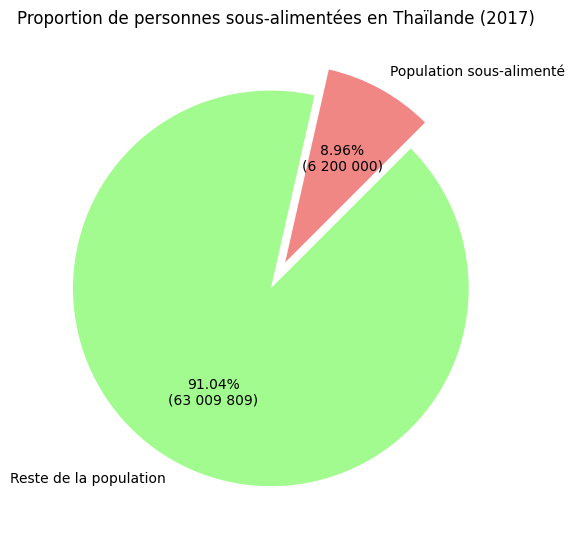

In [59]:
# On calcule la proportion exportée en fonction de la proportion

#thailande[["Zone", "proportion par pays"]].round(2)

population = thailande["Population"].values[0]
sous_nutrition = thailande["sous_nutrition"].values[0]
non_sous_nutrition = population - sous_nutrition

sous_nutrition/population * 100

values = [sous_nutrition, non_sous_nutrition]
labels = ["Population sous-alimenté", "Reste de la population"]

def autopct(pct):
    total = sum(values)
    val = pct/100 * total
    return f"{pct:.2f}%\n({int(val):,})".replace(",", " ")

plt.figure(figsize=(6,6))
ecart_part = (0.1, 0.05)
plt.pie(
    values, 
    labels=labels, 
    autopct=autopct, 
    startangle=45,
    colors=["#F08784", "#A1FB8E"],
    explode=ecart_part)
plt.title("Proportion de personnes sous-alimentées en Thaïlande (2017)")
plt.tight_layout()
plt.show()
#proportion de manioc exporté
#recherche internet / production/import

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [60]:
#ajouter en dessous toutes les analyses complémtaires

manioc_thailande = dataframe_dispo_alimentaire[
    (dataframe_dispo_alimentaire["Zone"] == "Thaïlande") &
    (dataframe_dispo_alimentaire["Produit"] == "Manioc")
]


manioc_thailande[[
    "Production",
    "Exportations - Quantité",
    "Disponibilité intérieure"
]]

,Production,Exportations - Quantité,Disponibilité intérieure
14166,30228000.0,25214000.0,6264000.0


In [61]:
manioc = dataframe_dispo_alimentaire[
    dataframe_dispo_alimentaire["Produit"] == "Manioc"
]

import_export_mondial = manioc["Importations - Quantité"].sum()
export_mondial = manioc["Exportations - Quantité"].sum()

import_export_par_pays = (
    manioc.groupby("Zone", as_index=False)[["Exportations - Quantité","Importations - Quantité"]]
    .sum()
)

import_export_par_pays["% import mondial"] = (
    import_export_par_pays["Importations - Quantité"] / export_mondial * 100
)
import_export_par_pays["% export mondial"] = (
    import_export_par_pays["Exportations - Quantité"] / export_mondial * 100
)

In [62]:
#tableau d'export du manioc
import_export_par_pays.sort_values("% export mondial", ascending=False).head(10)


,Zone,Exportations - Quantité,Importations - Quantité,% import mondial,% export mondial
146,Thaïlande,25214000.0,1250000.0,3.467695,69.947568
156,Viet Nam,8973000.0,0.0,0.000000,24.892501
68,Indonésie,820000.0,1102000.0,3.057120,2.274808
28,Cambodge,254000.0,0.0,0.000000,0.704636
114,Paraguay,164000.0,0.0,0.000000,0.454962
39,Costa Rica,123000.0,4000.0,0.011097,0.341221
34,"Chine, Taiwan Province de",82000.0,1324000.0,3.672982,0.227481
32,Chine - RAS de Hong-Kong,80000.0,92000.0,0.255222,0.221932
111,Ouganda,47000.0,1000.0,0.002774,0.130385
35,"Chine, continentale",41000.0,29046000.0,80.578134,0.113740


In [63]:
#tableau d'export du manioc
import_export_par_pays.sort_values("% import mondial", ascending=False).head(10)

,Zone,Exportations - Quantité,Importations - Quantité,% import mondial,% export mondial
35,"Chine, continentale",41000.0,29046000.0,80.578134,0.113740
124,République de Corée,0.0,1933000.0,5.362443,0.000000
34,"Chine, Taiwan Province de",82000.0,1324000.0,3.672982,0.227481
146,Thaïlande,25214000.0,1250000.0,3.467695,69.947568
68,Indonésie,820000.0,1102000.0,3.057120,2.274808
89,Malaisie,4000.0,844000.0,2.341388,0.011097
75,Japon,0.0,637000.0,1.767137,0.000000
163,États-Unis d'Amérique,9000.0,588000.0,1.631204,0.024967
116,Philippines,4000.0,276000.0,0.765667,0.011097
13,Bangladesh,0.0,147000.0,0.407801,0.000000


In [64]:
dispo_thailande = (
    dataframe_dispo_alimentaire[
        dataframe_dispo_alimentaire["Zone"] == "Thaïlande"
    ]
    .groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
)

production = manioc_thailande["Production"].values[0]
exportations = manioc_thailande["Exportations - Quantité"].values[0]
dispo_interieure = manioc_thailande["Disponibilité intérieure"].values[0]

f"{dispo_thailande.iloc[0]:.0f} kcal/personne/jour"

'2785 kcal/personne/jour'

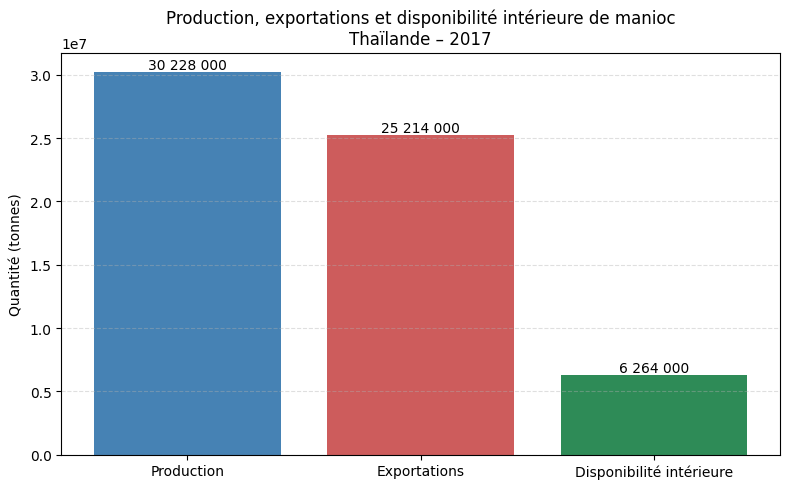

In [65]:
labels = ["Production", "Exportations", "Disponibilité intérieure"]
values = [production, exportations, dispo_interieure]

plt.figure(figsize=(8,5))
bars = plt.bar(
    labels,
    values,
    color=["steelblue", "indianred", "seagreen"]
)
# affichage des valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{int(height):,}".replace(",", " "),
             ha="center", va="bottom")


plt.title("Production, exportations et disponibilité intérieure de manioc\nThaïlande – 2017")
plt.ylabel("Quantité (tonnes)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

<div style="background-color: RGB(0,150,250);">
<h2 style="margin: auto; padding: 20px; color:#fff; ">Générations des graphs pour la présentation</h2>
</div>

In [66]:
dispo_kcal_mondial = dataframe_dispo_alimentaire["dispo_kcal"].sum()
humains_nourris = dispo_kcal_mondial / (2200 * 365)
humains_nourris

np.float64(9508629376.059546)

In [67]:
df_veg = dataframe_dispo_alimentaire[dataframe_dispo_alimentaire["Origine"] == "vegetale"].copy()
df_veg["dispo_kcal"] = (
    df_veg["Population"]
    * df_veg["Disponibilité alimentaire (Kcal/personne/jour)"]
    * 365
)

humains_nourris_vegetaux = df_veg["dispo_kcal"].sum() / (2200 * 365)
humains_nourris_vegetaux

np.float64(7845801914.318636)

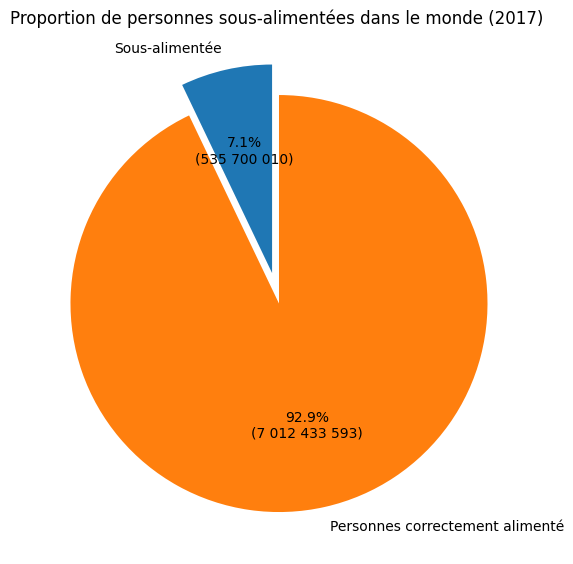

In [68]:
df_2017 = dataframe_merge[dataframe_merge["Année"] == 2017]

total_sous_nutrition = df_2017["sous_nutrition"].sum()
population_mondiale = df_2017["Population"].sum()

proportion_mondiale = total_sous_nutrition / population_mondiale
#f"{proportion_mondiale * 100:.2f}%"
#total_sous_nutrition
#population_mondiale
population_non_sous_alimentee = population_mondiale - total_sous_nutrition
labels = ["Sous-alimentée", "Personnes correctement alimenté"]
values = [total_sous_nutrition, population_non_sous_alimentee]

def autopct(pct):
    total = sum(values)
    val = pct/100 * total
    return f"{pct:.1f}%\n({int(val):,})".replace(",", " ")
ecart_part = (0.1, 0.05)

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct=autopct, startangle=90, explode=ecart_part)
plt.title("Proportion de personnes sous-alimentées dans le monde (2017)")
plt.tight_layout()
plt.show()

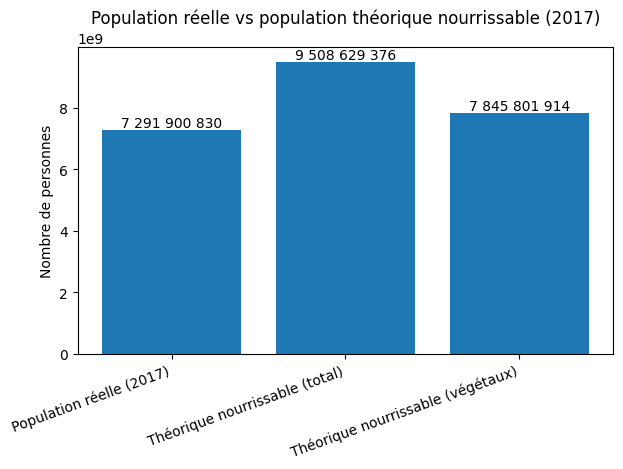

In [69]:
df = dataframe_dispo_alimentaire.copy()

# 1) Population mondiale réelle 2017 (évite le double comptage des produits)
pop_world = df[["Zone", "Population"]].drop_duplicates(subset=["Zone"])["Population"].sum()

# Heuristique simple si ta population est encore en "milliers" (lexique FAO)
# Si le total monde est < 200 millions, c'est quasi certain que c'est en milliers
if pop_world < 2e8:
    pop_world = pop_world * 1000

# 2) Théorique "nourrissable" (kcal/an -> personnes)
kcal_col = "Disponibilité alimentaire (Kcal/personne/jour)"

# dispo_kcal par ligne
df["dispo_kcal"] = df["Population"] * df[kcal_col] * 365
# même correction d'unité si Population est en milliers
if df[["Zone", "Population"]].drop_duplicates(subset=["Zone"])["Population"].sum() < 2e8:
    df["dispo_kcal"] *= 1000

humains_total = df["dispo_kcal"].sum() / (2200 * 365)

df_veg = df[df["Origine"] == "vegetale"]
humains_veg = df_veg["dispo_kcal"].sum() / (2200 * 365)

humains_animal = humains_total - humains_veg


labels = ["Population réelle (2017)", "Théorique nourrissable (total)", "Théorique nourrissable (végétaux)"]
values = [pop_world, humains_total, humains_veg]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Nombre de personnes")
plt.title("Population réelle vs population théorique nourrissable (2017)")
plt.xticks(rotation=20, ha="right")

# annotations (valeurs)
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,.0f}".replace(",", " "), ha="center", va="bottom")

plt.tight_layout()
plt.show()

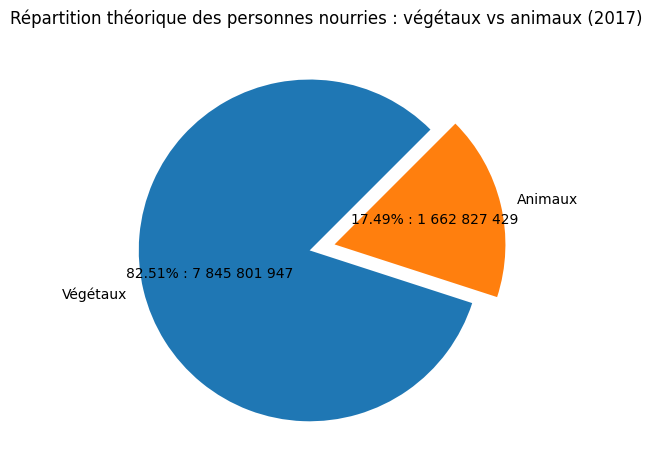

In [70]:
vals = [humains_veg, humains_animal]
names = ["Végétaux", "Animaux"]

total = sum(vals)
def autopct(pct):
    n = pct/100 * total
    return f"{pct:.2f}% : {n:,.0f}".replace(",", " ")
ecart_part = (0.1, 0.05)

plt.figure()
plt.pie(vals, labels=names, autopct=autopct, startangle=45, explode=ecart_part)
plt.title("Répartition théorique des personnes nourries : végétaux vs animaux (2017)")
plt.tight_layout()
plt.show()

Nourriture : 49.37%
Aliments pour animaux : 13.23%
Pertes : 4.65%
Semences : 1.58%
Traitement : 22.45%
Autres Utilisations : 8.82%


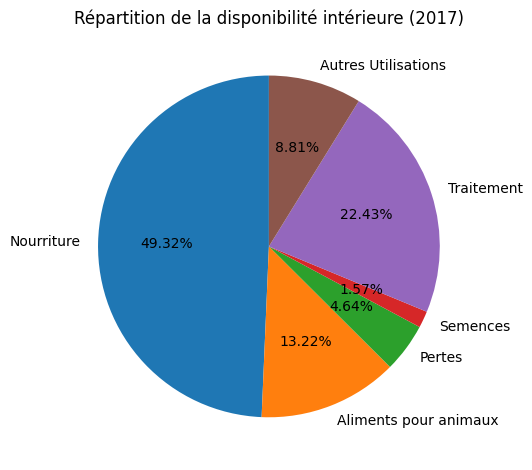

In [71]:
colonnes = [
    "Nourriture",
    "Aliments pour animaux",
    "Pertes",
    "Semences",
    "Traitement",
    "Autres Utilisations"
]

totaux = dataframe_dispo_alimentaire[colonnes].sum()
total_dispo = dataframe_dispo_alimentaire["Disponibilité intérieure"].sum()

pourcentages = (totaux / total_dispo) * 100
pourcentages.round(2)

for usage, pct in pourcentages.items():
    print(f"{usage} : {pct:.2f}%")

plt.figure()
plt.pie(pourcentages.values, labels=pourcentages.index, autopct="%.2f%%", startangle=90)
plt.title("Répartition de la disponibilité intérieure (2017)")
plt.tight_layout()
plt.show()






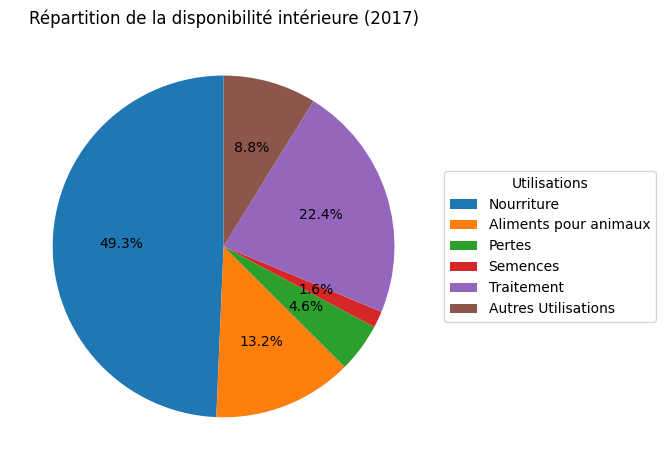

In [72]:
labels = pourcentages.index
values = pourcentages.values

plt.figure()
wedges, texts, autotexts = plt.pie(
    values,
    autopct="%.1f%%",
    startangle=90
)

plt.legend(
    wedges,
    labels,
    title="Utilisations",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Répartition de la disponibilité intérieure (2017)")
plt.tight_layout()
plt.show()

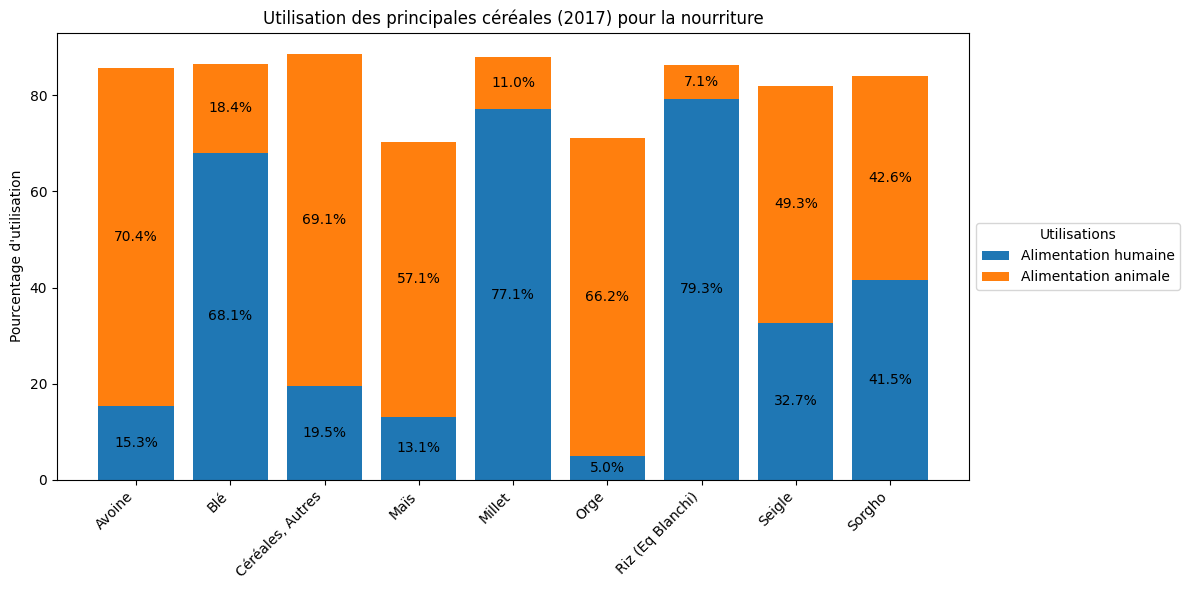

In [73]:
liste_cereales = [
    "Blé", "Riz (Eq Blanchi)", "Orge", "Maïs",
    "Seigle", "Avoine", "Millet", "Sorgho",
    "Céréales, Autres"
]

df_cereales = dataframe_dispo_alimentaire[
    dataframe_dispo_alimentaire["Produit"].isin(liste_cereales)
]

agg = df_cereales.groupby("Produit")[[
    "Nourriture",
    "Aliments pour animaux",
    "Disponibilité intérieure"
]].sum()

agg["% humaine"] = agg["Nourriture"] / agg["Disponibilité intérieure"] * 100
agg["% animale"] = agg["Aliments pour animaux"] / agg["Disponibilité intérieure"] * 100

plt.figure(figsize=(12, 6))

bars1 = plt.bar(agg.index, agg["% humaine"], label="Alimentation humaine")
bars2 = plt.bar(
    agg.index,
    agg["% animale"],
    bottom=agg["% humaine"],
    label="Alimentation animale"
)

# Ajout des pourcentages dans les barres
for i in range(len(agg)):
    # segment humain
    plt.text(i, agg["% humaine"].iloc[i] / 2,
             f"{agg['% humaine'].iloc[i]:.1f}%",
             ha="center", va="center")

    # segment animal
    plt.text(i,
             agg["% humaine"].iloc[i] + agg["% animale"].iloc[i] / 2,
             f"{agg['% animale'].iloc[i]:.1f}%",
             ha="center", va="center")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Pourcentage d'utilisation")
plt.title("Utilisation des principales céréales (2017) pour la nourriture")
plt.legend(
    title="Utilisations",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

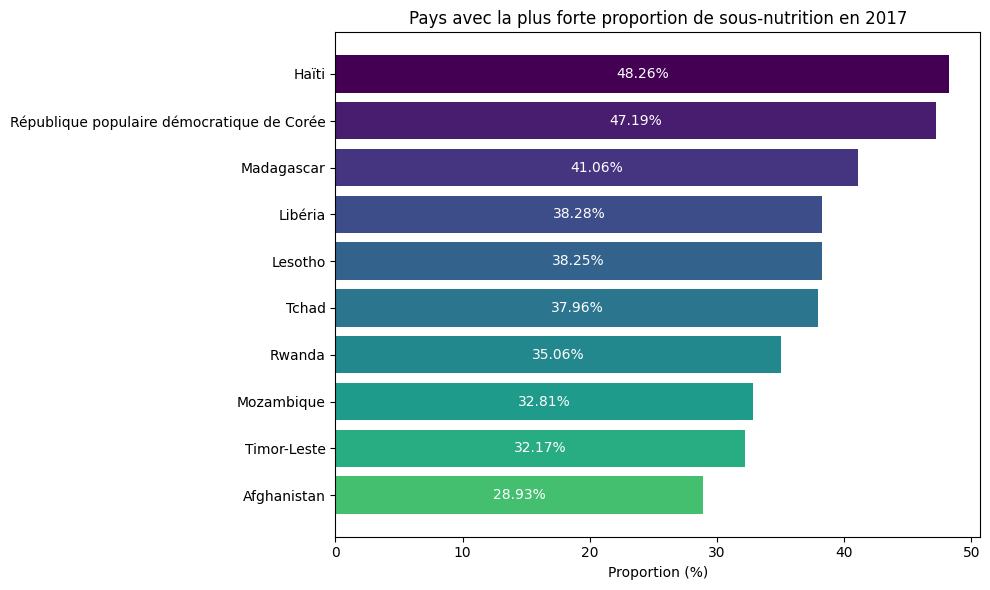

In [74]:
plt.figure(figsize=(10,6))
norm = plt.Normalize(top10["proportion par pays"].min(), top10["proportion par pays"].max())
#colors = plt.cm.Greens(norm(top10["proportion par pays"]))
#colors = plt.cm.Blues(np.linspace(0.4, 1, len(values)))
colors = plt.cm.viridis(np.linspace(0, 0.7, len(top10["proportion par pays"])))
bars = plt.barh(top10["Zone"], top10["proportion par pays"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Proportion (%)")
plt.bar_label(bars,
              fmt="%.2f%%",
              label_type="center",   # position au centre
    color="white")
plt.title("Pays avec la plus forte proportion de sous-nutrition en 2017")
plt.tight_layout()
plt.show()

In [75]:

aide_alimentaire_since_2013_2016 = aide_alimentaire[
    (aide_alimentaire["Année"] >= 2013) &
     (aide_alimentaire["Année"] <= 2016)
].groupby("Zone", as_index=False)["Valeur"].sum()
aide_alimentaire_since_2013_2016.sort_values(by="Valeur", ascending=False)[["Zone", "Valeur"]].head(10)

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


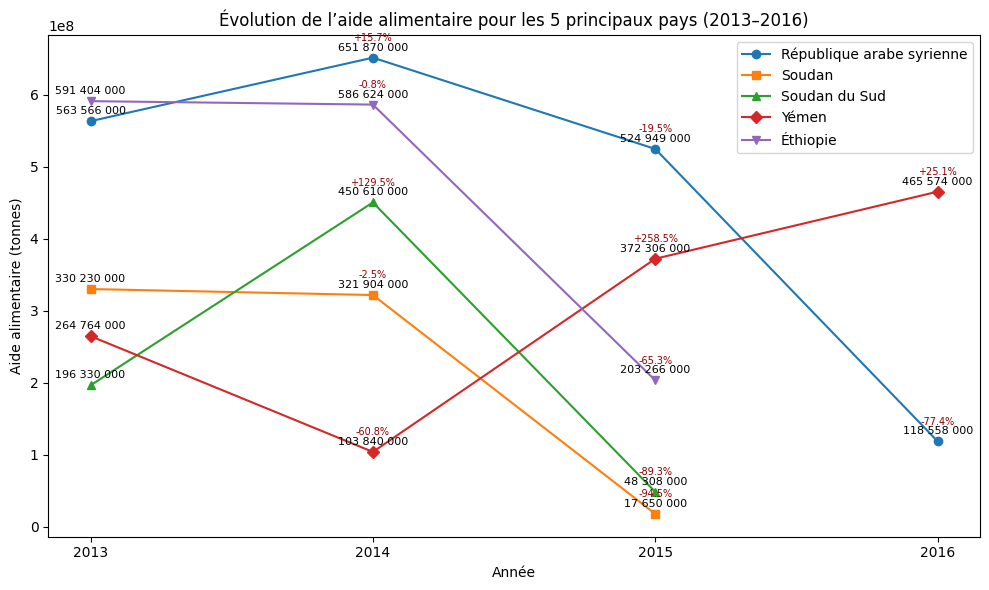

In [76]:
aide_2013_2016 = aide_alimentaire[
    aide_alimentaire["Année"].between(2013, 2016)
]
top5_pays = (
    aide_2013_2016
    .groupby("Zone")["Valeur"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

evolution_top5 = (
    aide_2013_2016[aide_2013_2016["Zone"].isin(top5_pays)]
    .groupby(["Zone", "Année"], as_index=False)["Valeur"]
    .sum()
)


plt.figure(figsize=(10,6))

styles = ["o", "s", "^", "D", "v"]
for i, pays in enumerate(evolution_top5["Zone"].unique()):
    data = evolution_top5[evolution_top5["Zone"] == pays].sort_values("Année")

    plt.plot(data["Année"], data["Valeur"], label=pays, linestyle="-", marker=styles[i % len(styles)])

    # calcul de l'évolution %
    data["evolution_pct"] = data["Valeur"].pct_change() * 100

    for x, y, pct in zip(data["Année"], data["Valeur"], data["evolution_pct"]):
        
        # texte principal (valeur)
        plt.annotate(
            f"{int(y):,}".replace(",", " "),
            (x, y),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=8
        )

        # texte évolution (si pas NaN sur la première année)
        if not pd.isna(pct):
            plt.annotate(
                f"{pct:+.1f}%",
                (x, y),
                textcoords="offset points",
                xytext=(0, 12),
                ha="center",
                fontsize=7,
                color="darkred"
            )

plt.xlabel("Année")
plt.ylabel("Aide alimentaire (tonnes)")
plt.title("Évolution de l’aide alimentaire pour les 5 principaux pays (2013–2016)")
plt.xticks([2013, 2014, 2015, 2016])
plt.legend()
plt.tight_layout()
plt.show()

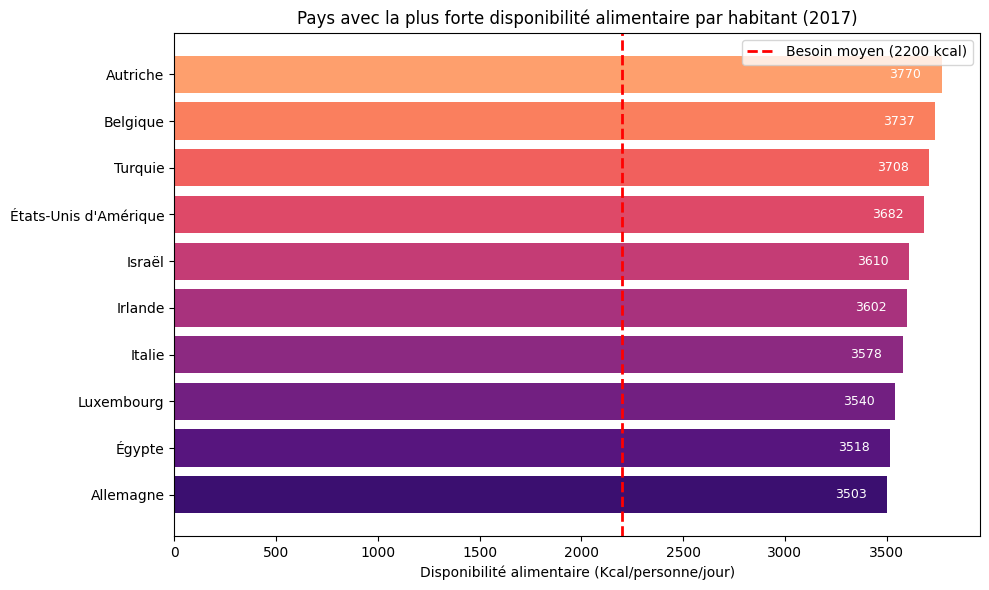

In [77]:
dispo_par_pays = (
    dataframe_dispo_alimentaire
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
)

top10_dispo = (
    dispo_par_pays
    .sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False)
    .head(10)
)


plt.figure(figsize=(10,6))

colors = plt.cm.magma(np.linspace(0.8, 0.2, len(top10_dispo["Disponibilité alimentaire (Kcal/personne/jour)"])))
bars = plt.barh(
    top10_dispo["Zone"],
    top10_dispo["Disponibilité alimentaire (Kcal/personne/jour)"],
    color=colors
)

plt.gca().invert_yaxis()

# ligne seuil 2200 kcal
plt.axvline(
    x=2200,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Besoin moyen (2200 kcal)"
)

# affichage des valeurs dans les barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 100,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        ha="right",
        color="white",
        fontsize=9
    )

plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.title("Pays avec la plus forte disponibilité alimentaire par habitant (2017)")
plt.legend()
plt.tight_layout()
plt.show()

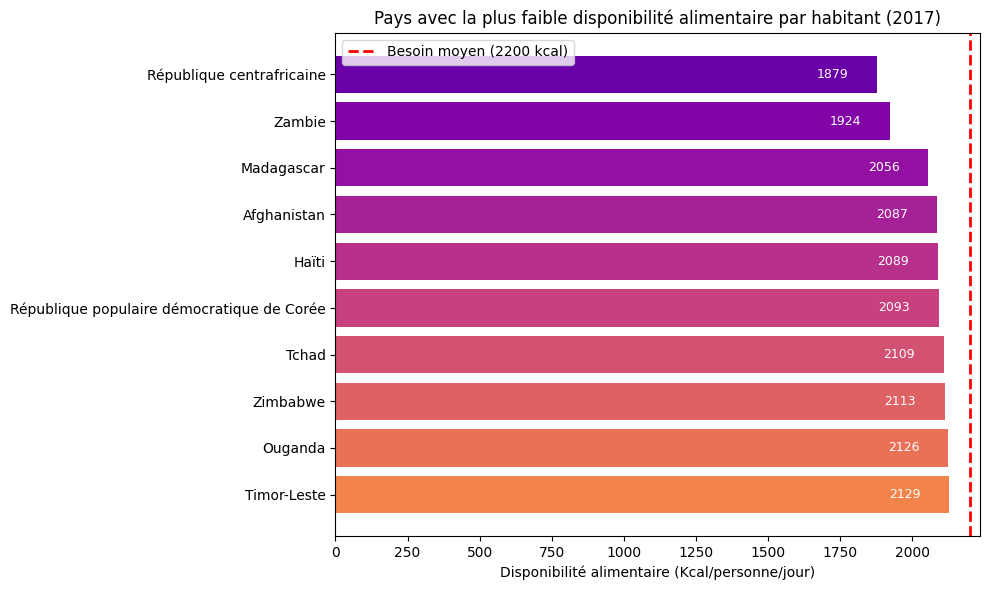

In [78]:
top10_revers_dispo = (
    dispo_par_pays
    .sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))

colors = plt.cm.plasma(np.linspace(0.2, 0.7, len(top10_revers_dispo["Disponibilité alimentaire (Kcal/personne/jour)"])))
bars = plt.barh(
    top10_revers_dispo["Zone"],
    top10_revers_dispo["Disponibilité alimentaire (Kcal/personne/jour)"],
    color=colors
)

plt.gca().invert_yaxis()

# ligne seuil 2200 kcal
plt.axvline(
    x=2200,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Besoin moyen (2200 kcal)"
)

# affichage des valeurs dans les barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 100,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        ha="right",
        color="white",
        fontsize=9
    )

plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)")
plt.title("Pays avec la plus faible disponibilité alimentaire par habitant (2017)")
plt.legend()
plt.tight_layout()
plt.show()